# Out-of-Sample Forecasting of Exchange Rate Expectations
Linear FE panel, Elastic Net, and XGBoost — expanding-window evaluation

Implements the model in `oos_forecasting_mathematical_model.tex`:

- Model 0 — naive random-walk benchmark
- Model 1 — linear two-way fixed-effects panel regression
- Model 2 — Elastic Net (regularized linear benchmark)
- Model 3 — XGBoost
- Expanding-window scheme with $\tau_0$, $\tau_{max}$
- RMSE / MAE, overall and AE/EMDE subgroups
- Diebold–Mariano test with the Harvey–Leybourne–Newbold small-sample correction
- Model Confidence Set (Hansen, Lunde & Nason 2011), block-bootstrap version
- SHAP importance stability across rounds (Kendall's $\tau$)

**Note on data:** no dataset was attached to the `.tex` file, so Section 1 below generates a synthetic panel with the exact variable names, $N$ countries, and $t_0$–$t_1$ described in the paper, purely so every downstream cell runs end-to-end. Replace that one cell with a loader for your real panel (same column names) and everything else runs unchanged.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
pd.set_option("display.precision", 4)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data setup (Section 1 of the paper)

Notation: $i$ indexes countries, $t$ indexes years. For each $(i, t)$ we have outcome $y_{i,t+h}$ at horizon $h$ and feature vector $x_{i,t}$.

Replace this cell with real data — keep the column names (`country`, `year`, the 8 feature columns, and `y_h3` / `y_h4`) and everything downstream is unaffected.

In [2]:
N = 29
YEARS = list(range(2008, 2022))          # 2008..2021
T = len(YEARS)
FEATURES = [
    "MP_Shock_Diff", "GDP_Forecast_Diff", "GDP_Forecast_Error",
    "CPI_Forecast_Diff", "CPI_Forecast_Error", "WUI_Shock_Diff",
    "Debt_to_GDP", "CBI",
]
d = len(FEATURES)

countries = [f"C{i:02d}" for i in range(1, N + 1)]
# arbitrary AE / EMDE split for the subgroup diagnostics -- replace with the real classification
AE_COUNTRIES = set(countries[:14])
EMDE_COUNTRIES = set(countries[14:])

rows = []
country_effect = rng.normal(0, 1.0, size=N)
year_effect = rng.normal(0, 0.5, size=T)
true_beta = rng.normal(0, 0.4, size=d)

for i, c in enumerate(countries):
    for t, yr in enumerate(YEARS):
        x = rng.normal(0, 1, size=d)
        x[6] = np.abs(rng.normal(60, 20))   # Debt_to_GDP
        x[7] = rng.uniform(0, 1)            # CBI index in [0,1]
        eps = rng.normal(0, 1.0)
        y3 = float(x @ true_beta + country_effect[i] + year_effect[t] + eps)
        y4 = float(x @ true_beta * 0.8 + country_effect[i] * 0.9 + year_effect[t] + rng.normal(0, 1.1))
        row = {"country": c, "year": yr}
        row.update({f: v for f, v in zip(FEATURES, x)})
        row["y_h3"] = y3
        row["y_h4"] = y4
        rows.append(row)

panel = pd.DataFrame(rows)
panel.head()

,country,year,MP_Shock_Diff,GDP_Forecast_Diff,GDP_Forecast_Error,CPI_Forecast_Diff,CPI_Forecast_Error,WUI_Shock_Diff,Debt_to_GDP,CBI,y_h3,y_h4
0,C01,2008,0.6313,-1.4572,-0.3197,-0.4704,-0.6389,-0.2751,79.3656,0.5652,2.0628,2.1707
1,C01,2009,0.5862,0.7112,0.7933,-0.3487,-0.4624,0.8580,37.3343,0.0583,3.1158,2.4962
2,C01,2010,0.6905,-0.4273,0.1585,0.6256,-0.3093,0.4568,52.3652,0.7224,2.4600,1.0519
3,C01,2011,0.0125,0.4807,0.4465,0.6654,-0.0985,-0.4233,31.0578,0.1180,0.0754,1.2771
4,C01,2012,-0.9055,-0.3782,1.2992,-0.3563,0.7375,-0.9336,53.2193,0.4558,-0.6380,1.2984


## 2. Expanding-window evaluation scheme (Definition 1)

$\tau_0$, $\tau_{max}$, for $\tau = \tau_0, \dots, \tau_{max}-1$, giving $R$ rounds.

In [3]:
TAU0 = 2015
TAU_MAX = 2021
ROUNDS = list(range(TAU0, TAU_MAX))   # tau = 2015..2020, forecasting tau+1
print(f"R = {len(ROUNDS)} evaluation rounds: {ROUNDS} (forecasting {[t+1 for t in ROUNDS]})")

def get_train_test(panel, tau):
    train = panel[panel["year"] <= tau].copy()
    test = panel[panel["year"] == tau + 1].copy()
    return train, test

R = 6 evaluation rounds: [2015, 2016, 2017, 2018, 2019, 2020] (forecasting [2016, 2017, 2018, 2019, 2020, 2021])


## 3. Candidate models (Section 2)

**Model 0 — naive random walk:** $\hat{y} = 0$

In [4]:
def forecast_model0(test):
    return pd.Series(0.0, index=test.index)

**Model 1 — linear two-way fixed-effects panel (Eq. 4-6)**

Within-transformation least squares on the country- and year-demeaned data. Since the year effect is not identified for the forecast year, the last estimated country effect is carried forward for the forecast.

In [5]:
def fit_predict_fe(train, test, horizon_col):
    df = train.copy()
    country_means = df.groupby("country")[FEATURES + [horizon_col]].transform("mean")
    year_means = df.groupby("year")[FEATURES + [horizon_col]].transform("mean")
    grand_mean = df[FEATURES + [horizon_col]].mean()
    demeaned = df[FEATURES + [horizon_col]] - country_means - year_means + grand_mean

    X_tilde = demeaned[FEATURES].values
    y_tilde = demeaned[horizon_col].values
    XtX = X_tilde.T @ X_tilde
    beta = np.linalg.solve(XtX + 1e-8 * np.eye(d), X_tilde.T @ y_tilde)

    fitted_train = df[FEATURES].values @ beta
    resid = df[horizon_col].values - fitted_train
    country_eff = pd.Series(resid, index=df.index).groupby(df["country"]).mean()

    preds = test[FEATURES].values @ beta + test["country"].map(country_eff).values
    return pd.Series(preds, index=test.index), beta

**Model 2 — Elastic Net (Eq. 7)**

Estimated on the pooled (non-demeaned) data; hyperparameters are selected by cross-validation strictly within the training window (no leakage from the test window).

In [6]:
def fit_predict_enet(train, test, horizon_col):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(train[FEATURES].values)
    ytr = train[horizon_col].values
    Xte = scaler.transform(test[FEATURES].values)

    n_splits = min(5, train["year"].nunique())
    model = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=100, cv=max(2, n_splits), max_iter=10000, random_state=0,
    )
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    return pd.Series(preds, index=test.index), model

**Model 3 — XGBoost (Eq. 8-10)**

Additive tree ensemble trained by the standard second-order (Newton) boosting objective. Hyperparameters are chosen by a small nested expanding-window search inside the training window only (mirrors the paper's "nested cross-validation strictly within the training window"). Expand the grid below for a more exhaustive search on real data.

In [7]:
def fit_predict_xgb(train, test, horizon_col):
    X = train[FEATURES].values
    y = train[horizon_col].values
    dtrain_full = xgb.DMatrix(X, label=y, feature_names=FEATURES)

    grid = [
        dict(max_depth=2, eta=0.05, min_child_weight=3),
        dict(max_depth=3, eta=0.05, min_child_weight=3),
        dict(max_depth=3, eta=0.1, min_child_weight=5),
    ]
    inner_years = sorted(train["year"].unique())
    best_params, best_rmse = None, np.inf

    if len(inner_years) >= 3:
        inner_tau0 = inner_years[max(0, len(inner_years) - 3)]
        for params in grid:
            errs = []
            for inner_tau in [yy for yy in inner_years if yy >= inner_tau0 and yy < inner_years[-1]]:
                itr = train[train["year"] <= inner_tau]
                ite = train[train["year"] == inner_tau + 1]
                if len(ite) == 0 or len(itr) == 0:
                    continue
                dtr = xgb.DMatrix(itr[FEATURES].values, label=itr[horizon_col].values, feature_names=FEATURES)
                dte = xgb.DMatrix(ite[FEATURES].values, label=ite[horizon_col].values, feature_names=FEATURES)
                bst = xgb.train(
                    {**params, "objective": "reg:squarederror", "lambda": 1.0, "gamma": 0.0, "verbosity": 0},
                    dtr, num_boost_round=100,
                )
                pred = bst.predict(dte)
                errs.append(np.sqrt(np.mean((ite[horizon_col].values - pred) ** 2)))
            if errs:
                mrmse = np.mean(errs)
                if mrmse < best_rmse:
                    best_rmse, best_params = mrmse, params

    if best_params is None:
        best_params = grid[1]

    full_params = {**best_params, "objective": "reg:squarederror", "lambda": 1.0, "gamma": 0.0, "verbosity": 0}
    bst = xgb.train(full_params, dtrain_full, num_boost_round=100)
    dtest = xgb.DMatrix(test[FEATURES].values, feature_names=FEATURES)
    preds = bst.predict(dtest)
    return pd.Series(preds, index=test.index), bst

## 4. Expanding-window forecast loop

Runs all four models at every round $\tau$, collects the pooled evaluation sample $S$, and records SHAP importances for the XGBoost model at each round (used in Section 8 below).

In [8]:
def run_horizon(panel, horizon_col):
    results = []
    shap_importances = {}
    for tau in ROUNDS:
        train, test = get_train_test(panel, tau)
        if test.empty or train.empty:
            continue

        p0 = forecast_model0(test)
        p1, _ = fit_predict_fe(train, test, horizon_col)
        p2, _ = fit_predict_enet(train, test, horizon_col)
        p3, bst = fit_predict_xgb(train, test, horizon_col)

        explainer = shap.TreeExplainer(bst)
        sv = explainer.shap_values(train[FEATURES].values)
        shap_importances[tau] = np.mean(np.abs(sv), axis=0)

        out = test[["country", "year"]].copy()
        out["y_true"] = test[horizon_col].values
        out["yhat_m0"] = p0.values
        out["yhat_m1"] = p1.values
        out["yhat_m2"] = p2.values
        out["yhat_m3"] = p3.values
        out["tau"] = tau
        results.append(out)

    S = pd.concat(results, ignore_index=True)
    for m in [0, 1, 2, 3]:
        S[f"e_m{m}"] = S["y_true"] - S[f"yhat_m{m}"]
    shap_df = pd.DataFrame(shap_importances, index=FEATURES).T   # rows = tau, cols = features
    return S, shap_df

# Run for h=3; re-run with "y_h4" for the other horizon
S3, shap3 = run_horizon(panel, "y_h3")
print(f"Pooled evaluation sample size |S| = {len(S3)}  (R x N = {len(ROUNDS)} x {N})")
S3.head()

Pooled evaluation sample size |S| = 174  (R x N = 6 x 29)


,country,year,y_true,yhat_m0,yhat_m1,yhat_m2,yhat_m3,tau,e_m0,e_m1,e_m2,e_m3
0,C01,2016,2.9817,0.0,1.7352,2.0524,1.6028,2015,2.9817,1.2465,0.9293,1.3789
1,C02,2016,2.2210,0.0,1.7383,1.9396,2.2054,2015,2.2210,0.4827,0.2814,0.0156
2,C03,2016,2.4082,0.0,2.2222,1.7415,1.5950,2015,2.4082,0.1861,0.6668,0.8133
3,C04,2016,4.5295,0.0,2.8052,2.2114,1.8859,2015,4.5295,1.7243,2.3181,2.6436
4,C05,2016,-1.1424,0.0,-0.1123,1.8127,1.9075,2015,-1.1424,-1.0301,-2.9551,-3.0499


## 5. RMSE / MAE, overall and AE/EMDE subgroups (Eq. 11-12)

$RMSE = \sqrt{\frac{1}{|S|}\sum e^2}$, $MAE = \frac{1}{|S|}\sum |e|$, restricted to the AE / EMDE country subsets for the subgroup versions.

In [9]:
def rmse(e): return float(np.sqrt(np.mean(e ** 2)))
def mae(e):  return float(np.mean(np.abs(e)))

def accuracy_table(S):
    rows = []
    for m in [0, 1, 2, 3]:
        e = S[f"e_m{m}"]
        e_ae = S.loc[S["country"].isin(AE_COUNTRIES), f"e_m{m}"]
        e_emde = S.loc[S["country"].isin(EMDE_COUNTRIES), f"e_m{m}"]
        rows.append({"model": m, "RMSE": rmse(e), "MAE": mae(e),
                     "RMSE_AE": rmse(e_ae), "RMSE_EMDE": rmse(e_emde)})
    return pd.DataFrame(rows).set_index("model")

acc3 = accuracy_table(S3)
acc3

,RMSE,MAE,RMSE_AE,RMSE_EMDE
model,,,,
0,2.1798,1.8755,2.3601,1.9969
1,1.1327,0.8997,1.2590,1.0006
2,1.3539,1.0562,1.5728,1.1115
3,1.3823,1.0455,1.5979,1.1451


## 6. Diebold–Mariano test with the HLN small-sample correction (Section 4)

Loss differential $d_t = L(e_{m,t}) - L(e_{m',t})$, tested against $H_0: E[d_t]=0$ using a Newey–West-type long-run variance and the Harvey–Leybourne–Newbold (1997) correction, compared against a Student-$t$ distribution.

In [10]:
def diebold_mariano(e_m, e_mprime, loss="sq", h_step=1, q=None):
    if loss == "sq":
        Lm, Lmp = e_m ** 2, e_mprime ** 2
    else:
        Lm, Lmp = np.abs(e_m), np.abs(e_mprime)
    d = np.asarray(Lm - Lmp, dtype=float)
    n = len(d)
    dbar = d.mean()

    if q is None:
        q = max(h_step - 1, 0)

    gamma0 = np.mean((d - dbar) ** 2)
    var_d = gamma0
    for k in range(1, q + 1):
        gamma_k = np.mean((d[k:] - dbar) * (d[:-k] - dbar))
        var_d += 2 * (1 - k / (q + 1)) * gamma_k
    var_dbar = var_d / n

    if var_dbar <= 0:
        return np.nan, np.nan

    DM = dbar / np.sqrt(var_dbar)
    correction = np.sqrt((n + 1 - 2 * h_step + h_step * (h_step - 1) / n) / n)
    DM_hln = correction * DM
    p_value = 2 * (1 - stats.t.cdf(np.abs(DM_hln), df=n - 1))
    return DM_hln, p_value

def hypothesis_tests(S, loss="sq"):
    pairs = {
        "H0(a): FE(1) vs XGB(3)": (1, 3),
        "H0(b): RW(0) vs XGB(3)": (0, 3),
        "H0(c): ENet(2) vs XGB(3)": (2, 3),
    }
    rows = []
    for name, (m, mp) in pairs.items():
        stat, p = diebold_mariano(S[f"e_m{m}"].values, S[f"e_m{mp}"].values, loss=loss)
        rows.append({"hypothesis": name, "DM_HLN": stat, "p_value": p})

    e3_ae = S.loc[S["country"].isin(AE_COUNTRIES), "e_m3"].values
    e3_emde = S.loc[S["country"].isin(EMDE_COUNTRIES), "e_m3"].values
    n = min(len(e3_ae), len(e3_emde))
    stat, p = diebold_mariano(e3_ae[:n], e3_emde[:n], loss=loss)
    rows.append({"hypothesis": "H0(d): XGB AE vs XGB EMDE", "DM_HLN": stat, "p_value": p})
    return pd.DataFrame(rows)

tests3 = hypothesis_tests(S3)
tests3

,hypothesis,DM_HLN,p_value
0,H0(a): FE(1) vs XGB(3),-3.0866,2.3584e-03
1,H0(b): RW(0) vs XGB(3),6.8339,1.3554e-10
2,H0(c): ENet(2) vs XGB(3),-1.0117,3.1311e-01
3,H0(d): XGB AE vs XGB EMDE,2.4707,1.5532e-02


A negative $DM_{HLN}$ on H0(b) with $p<0.05$ would reject "random walk = XGBoost" in XGBoost's favor — genuine out-of-sample forecastability, addressing the Meese–Rogoff puzzle. Rejecting H0(c) in XGBoost's favor attributes the gain to nonlinearity specifically, not just shrinkage/regularization.

## 7. Model Confidence Set — robustness check (Section 5)

Hansen, Lunde & Nason (2011) procedure via (circular) block bootstrap: iteratively drop the worst-performing model while the equivalence statistic exceeds its bootstrap-derived critical value.

In [11]:
def model_confidence_set(S, models=(0, 1, 2, 3), loss="sq", alpha=0.10, B=2000, block=4, seed=0):
    rng_local = np.random.default_rng(seed)
    L = np.column_stack([
        (S[f"e_m{m}"].values ** 2) if loss == "sq" else np.abs(S[f"e_m{m}"].values)
        for m in models
    ])
    n = L.shape[0]
    active = list(range(len(models)))

    def block_bootstrap_indices(n, block, B, rng_local):
        idx = np.zeros((B, n), dtype=int)
        n_blocks = int(np.ceil(n / block))
        for b in range(B):
            starts = rng_local.integers(0, n, size=n_blocks)
            seq = np.concatenate([np.arange(s, s + block) % n for s in starts])[:n]
            idx[b] = seq
        return idx

    boot_idx = block_bootstrap_indices(n, block, B, rng_local)
    eliminated_order = []

    while len(active) > 1:
        Lsub = L[:, active]
        Lboot = Lsub[boot_idx]                                  # B x n x k
        d_ij = Lsub.mean(axis=0)[:, None] - Lsub.mean(axis=0)[None, :]
        var_ij = np.var(
            Lboot.mean(axis=1)[:, :, None] - Lboot.mean(axis=1)[:, None, :], axis=0
        ) + 1e-12
        t_ij = np.abs(d_ij) / np.sqrt(var_ij)
        np.fill_diagonal(t_ij, 0)
        Tmax_obs = t_ij.max()

        Tmax_boot = np.zeros(B)
        for b in range(B):
            db = Lboot[b].mean(axis=0)
            dd = db[:, None] - db[None, :]
            Tmax_boot[b] = np.abs(dd / np.sqrt(var_ij + 1e-12)).max()

        pval = np.mean(Tmax_boot >= Tmax_obs)
        if pval > alpha:
            break

        worst_idx = np.argmax(Lsub.mean(axis=0))
        eliminated_order.append((models[active[worst_idx]], pval))
        active.pop(worst_idx)

    surviving = [models[i] for i in active]
    return surviving, eliminated_order

mcs_models, mcs_elim = model_confidence_set(S3, B=1000)
print("MCS surviving models (alpha=0.10):", mcs_models)
print("Elimination order [(model, MCS p-value), ...]:", mcs_elim)

MCS surviving models (alpha=0.10): [0, 1, 2, 3]
Elimination order [(model, MCS p-value), ...]: []


## 8. Post-hoc SHAP stability diagnostic (Section 6)

Global SHAP importance per feature, recomputed at every round $\tau$. Rank stability across consecutive rounds via Kendall's $\tau$; low/unstable values would temper the causal interpretation of any single round's SHAP ranking.

In [12]:
def shap_stability(shap_df):
    taus = sorted(shap_df.index)
    rows = []
    for k in range(1, len(taus)):
        r_now = shap_df.loc[taus[k]].rank()
        r_prev = shap_df.loc[taus[k - 1]].rank()
        tau_corr, p = stats.kendalltau(r_now, r_prev)
        rows.append({"tau": taus[k], "kendall_tau": tau_corr, "p_value": p})
    return pd.DataFrame(rows)

stability3 = shap_stability(shap3)
stability3

,tau,kendall_tau,p_value
0,2016,0.8571,0.0017
1,2017,0.7143,0.0141
2,2018,0.8571,0.0017
3,2019,0.8571,0.0017
4,2020,0.8571,0.0017


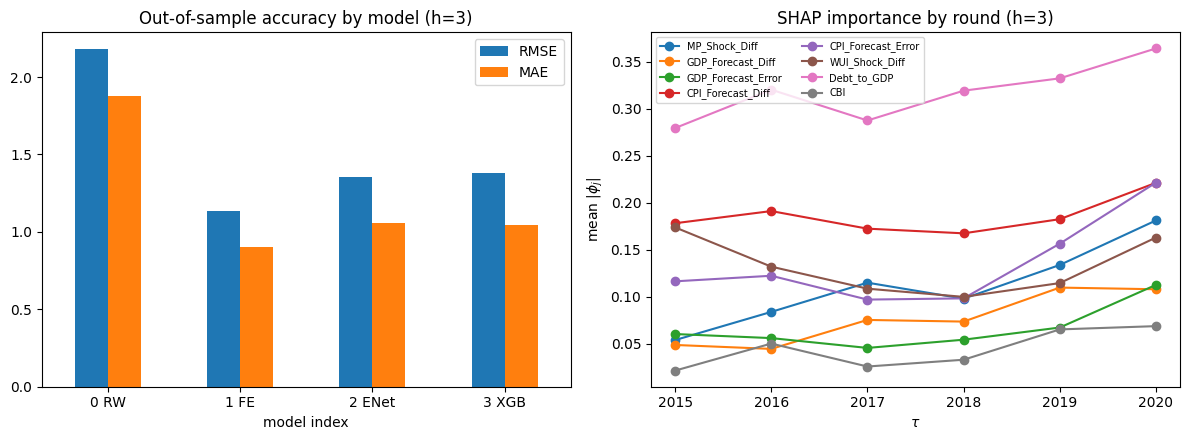

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

acc3[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Out-of-sample accuracy by model (h=3)")
axes[0].set_xlabel("model index")
axes[0].set_xticklabels(["0 RW", "1 FE", "2 ENet", "3 XGB"], rotation=0)

shap3.plot(ax=axes[1], marker="o")
axes[1].set_title("SHAP importance by round (h=3)")
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel(r"mean $|\phi_j|$")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 9. Re-run for the other horizon ($h=4$)

Everything above is a function of `horizon_col`; swap it and re-run to get the $h=4$ counterparts of every table.

In [14]:
S4, shap4 = run_horizon(panel, "y_h4")
acc4 = accuracy_table(S4)
tests4 = hypothesis_tests(S4)
stability4 = shap_stability(shap4)

print("h=4 accuracy:"); display(acc4)
print("h=4 DM tests:"); display(tests4)
print("h=4 SHAP stability:"); display(stability4)

h=4 accuracy:


,RMSE,MAE,RMSE_AE,RMSE_EMDE
model,,,,
0,1.8460,1.4533,1.7209,1.9555
1,1.1958,0.9546,1.1055,1.2742
2,1.3030,1.0898,1.2315,1.3664
3,1.3493,1.1261,1.2841,1.4075


h=4 DM tests:


,hypothesis,DM_HLN,p_value
0,H0(a): FE(1) vs XGB(3),-2.6645,8.4393e-03
1,H0(b): RW(0) vs XGB(3),5.0184,1.2855e-06
2,H0(c): ENet(2) vs XGB(3),-1.4901,1.3801e-01
3,H0(d): XGB AE vs XGB EMDE,-0.9323,3.5388e-01


h=4 SHAP stability:


,tau,kendall_tau,p_value
0,2016,0.8571,0.0017
1,2017,0.8571,0.0017
2,2018,0.9286,0.0004
3,2019,0.8571,0.0017
4,2020,0.7143,0.0141
